# 정규분포 & 이어지는 분포들
$$ X\sim N(\mu, \sigma^2 ) \to K\sim \chi_H^2  \to  T \sim t_{df}  \to  F \sim F_{df_1, df_2 }  $$

## 정규분포
밀도, 확률, 경계값, 분포표, 등

In [1]:
# 정규분포표 표 작성
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats   # 이렇게 하면 stats.norm(어쩌구)
from scipy.stats import norm, t, chi2, f  # 이렇게 하면 norm(어쩌구...


$ X \sim N(\mu, \sigma^2 ) $, 이때, $ X $의 밀도 at $ x $.
$$ f(x) = {1 \over \sqrt{2 \pi \sigma^2} } e^{ -{1 \over 2\sigma^2} (x - \mu)^2 } $$

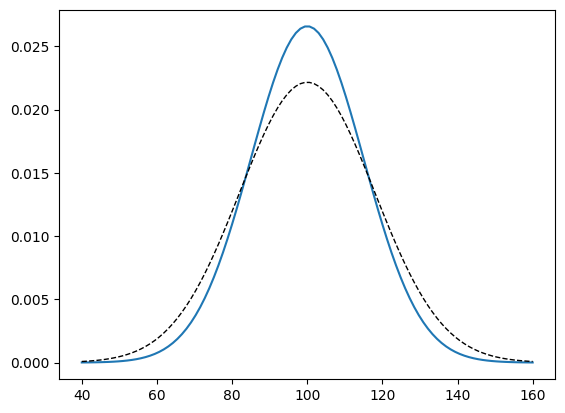

In [2]:
# 정규분포의 pdf 생성

# * **다양한 확률분포 기반 난수 생성 (`np.random` / `scipy.stats`):**
# * **정규분포:** `np.random.normal(loc=평균, scale=표준편차, size=크기)`
# * **균일분포:** `np.random.uniform(low=최솟값, high=최댓값, size=크기)`
# * **이항분포:** `np.random.binomial(n=시도횟수, p=확률, size=크기)`
# * **포아송분포:** `np.random.poisson(lam=평균발생횟수, size=크기)`

mu, sig = 100, 15
x = np.linspace(mu-4*sig, mu+4*sig, 100)
y = norm.pdf(x, loc=mu, scale=sig)
p = norm.cdf(x, loc=mu, scale=sig)
plt.plot(x, y)   # density

# 정규분포의 pdf 함수 f(x) 정의.
def norm_density(x, mu, sig ) :
    y = ( 1 / np.sqrt(2 * np.pi * sig**2 )) * np.exp( - 1 / ( 2 * sig**2 ) * (x - mu)**2 )
    return y

z = norm_density(x, mu, sig*1.2)  # 평균은 같고, 표준편차는 큰 경우, 비교용.
plt.plot(x, z, lw=1, color='black', linestyle='--')


## 정규분포의 누적확률, 유의수준에 대응되는 경계값
$ p = P(X < x) $,

$ x $ s.t. $ P(X < x) = { \alpha \over 2 } $

P(Z <= -1.5) = 0.0668
P(X <= -1.9599639845400545) = 0.0250
P(X <= 1.959963984540054) = 0.9750


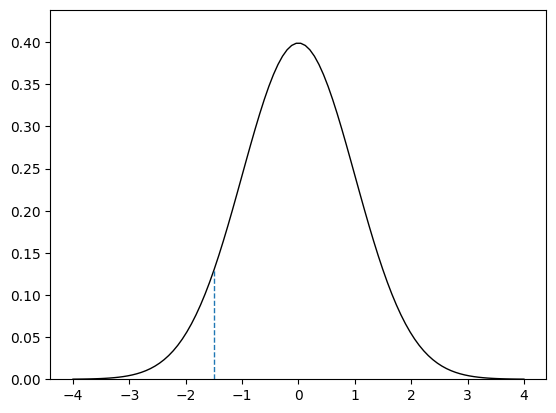

In [3]:
mu, sig = 0, 1
x = np.linspace(mu-4*sig, mu+4*sig, 100)
y = norm.pdf(x, loc=mu, scale=sig)
y_max = max(y)
p = norm.cdf(x, loc=mu, scale=sig)

x_ref  = mu - 1.5 * sig                    # 임의의 경계점, 정규분포에 대응해서.
x_look = [ x_ref, x_ref ]     # 경계선 표시
y_look = [0, norm.pdf(x_look[1], mu, sig)]

plt.plot(x, y, color='black', lw=1)   # density
plt.plot(x_look, y_look, lw=1, linestyle='--') # reference line
plt.ylim(0, y_max*1.1)

x = x_look[1]
p = norm.cdf(x, mu, sig)
print(f'P(Z <= {x}) = {p:.4f}')

alpha = 0.05
z_lft = norm.ppf(alpha/2, mu, sig )
z_rgt = norm.ppf(1 - alpha/2, mu , sig )
print(f'P(X <= {z_lft}) = {alpha/2:.4f}')
print(f'P(X <= {z_rgt}) = {1 - alpha/2:.4f}')

## $ \chi^2 $ distribution

\begin{align}
K & = Z_1^2 + Z_2^2 + \cdots + Z_H^2 \\
  & \sim \chi_H^2  
\end{align}
$ Z_i, Z_j $ 서로 독립 $ \forall i, j $. df = $ H $.

P(K <= 12.5) = 0.0179
P(X <= 13.11972002493778, df = 25 ) = 0.0250
P(X <= 40.6464691202752, df = 25 ) = 0.9750


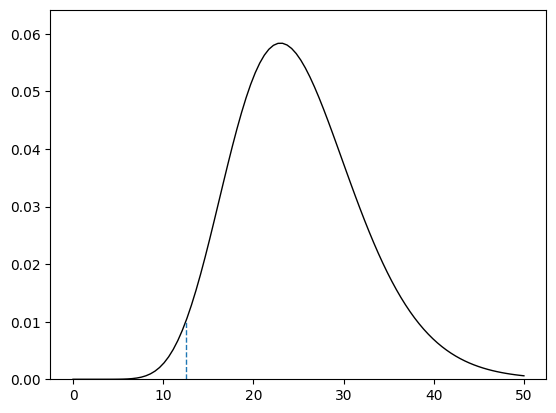

In [4]:
df_h = 25
x = np.linspace(0, 2*df_h, 100)   # 살펴본 만한 x의 구간
y = chi2.pdf(x, df=df_h)
y_max = max(y)
#p = chi2.cdf(x, df=df_h)

sm_chi = df_h / 2                     # 임의의 경계점, 정규분포에 대응해서.
x_look = [ sm_chi, sm_chi ]       # 경계선 표시 누적확률 계산할 경계선 표시
y_look = [0, chi2.pdf(x_look[1], df=df_h) ]

plt.plot(x, y, color='black', lw=1)   # density
plt.plot(x_look, y_look, lw=1, linestyle='--') # reference line
plt.ylim(0, y_max*1.1)

x = x_look[1]
p = chi2.cdf(x, df=df_h)
print(f'P(K <= {x}) = {p:.4f}')

alpha = 0.05
z_lft = chi2.ppf(alpha/2, df = df_h)
z_rgt = chi2.ppf(1 - alpha/2, df = df_h )
print(f'P(X <= {z_lft}, df = {df_h} ) = {alpha/2:.4f}')
print(f'P(X <= {z_rgt}, df = {df_h} ) = {1 - alpha/2:.4f}')

## $ t $ distribution

\begin{align}
T & = { Z \over K /df } \\
 & \sim t_{ df }
\end{align}
$ Z, K $ 서로 독립


P(Z <= -1.5) = 0.0668
P(T <= -1.5, df=5) = 0.0970
P(T <= -2.5705818356363146, df=5) = 0.0250
P(T <= 2.570581835636314, df=5) = 0.9750


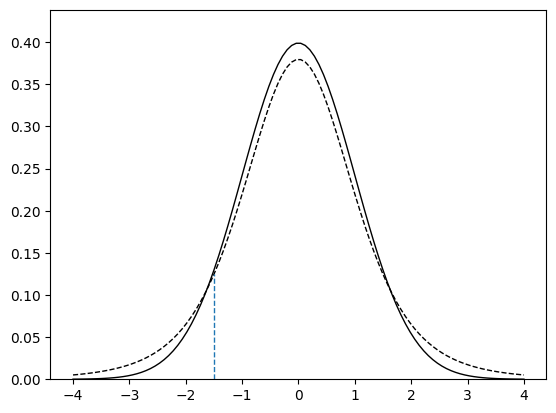

In [5]:
df_t = 5
mu, sig = 0, 1
x = np.linspace(mu-4*sig, mu+4*sig, 100)
y_n = norm.pdf(x, loc=mu, scale=sig)
y_t = t.pdf(x, df=df_t)
y_max = max(y_n)
#p = norm.cdf(x, loc=mu, scale=sig)

sm_t = mu - 1.5 * sig            # 임의의 경계점, 정규분포에 대응해서.
x_look = [ sm_t, sm_t ]          # 경계선 표시 누적확률 계산할 경계선 표시
#x_look = [ mu-1.5*sig, mu - 1.5*sig]     # 경계선 표시
y_look = [0, t.pdf(x_look[1], df=df_t)]

plt.plot(x, y_n, color='black', lw=1)   # density, N(0,1)
plt.plot(x, y_t, color='black', lw=1, linestyle='--')   # density, N(0,1)
plt.plot(x_look, y_look, lw=1, linestyle='--') # reference line
plt.ylim(0, y_max*1.1)

x = x_look[1]
p_n = norm.cdf(x, mu, sig)
p_t = t.cdf(x, df=df_t)
print(f'P(Z <= {x}) = {p_n:.4f}')
print(f'P(T <= {x}, df={df_t}) = {p_t:.4f}')

alpha = 0.05
z_lft = t.ppf(alpha/2,  df=df_t)
z_rgt = t.ppf(1 - alpha/2,  df=df_t)
print(f'P(T <= {z_lft}, df={df_t}) = {alpha/2:.4f}')
print(f'P(T <= {z_rgt}, df={df_t}) = {1 - alpha/2:.4f}')

## $ F $ distribution

\begin{align}
F & = { K_1 /df_1 \over K_2 /df_2 } \\
 & \sim F_{( df_1, df_2 )}
\end{align}

$ K_1, K_2 $ 서로 독립.


P(F <= 0.6,  dfn = 25, dfd = 21 ) = 0.1109
P(F <= 0.437820735195501,  dfn = 25, dfd = 21 ) = 0.0250
P(F <= 2.355839495343019,  dfn = 25, dfd = 21 ) = 0.9750


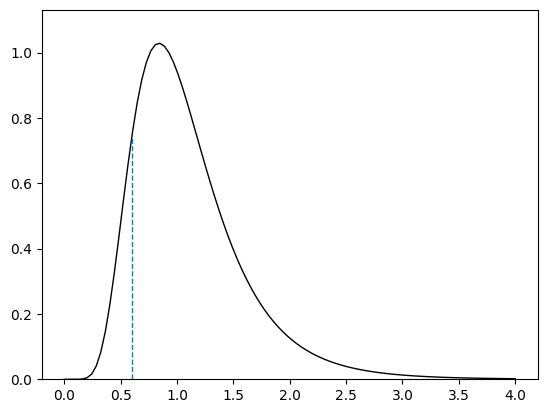

In [6]:
df_1 = 25
df_2 = 21

x = np.linspace(0, 4, 100)
y = f.pdf(x, dfn = df_1, dfd = df_2 )
y_max = max(y)
#p = norm.cdf(x, loc=mu, scale=sig)

sm_f = 0.6                       # 임의의 경계점, 정규분포에 대응해서.
x_look = [ sm_f, sm_f ]          # 경계선 표시 누적확률 계산할 경계선 표시
y_look = [0, f.pdf(x_look[1],  dfn = df_1, dfd = df_2 ) ]

plt.plot(x, y, color='black', lw=1)   # density
plt.plot(x_look, y_look, lw=1, linestyle='--') # reference line
plt.ylim(0, y_max*1.1)

x = x_look[1]
p = f.cdf(x,  dfn = df_1, dfd = df_2 )
print(f'P(F <= {x},  dfn = {df_1}, dfd = {df_2} ) = {p:.4f}')

alpha = 0.05
z_lft = f.ppf(alpha/2,  dfn = df_1, dfd = df_2 )
z_rgt = f.ppf(1 - alpha/2,  dfn = df_1, dfd = df_2 )
print(f'P(F <= {z_lft},  dfn = {df_1}, dfd = {df_2} ) = {alpha/2:.4f}')
print(f'P(F <= {z_rgt},  dfn = {df_1}, dfd = {df_2} ) = {1 - alpha/2:.4f}')